Powerlifting Cohort Shift - Age Curve Over Time

William Le - 06/07/2026

Headline figure showed median age of the top 50 dropping. This notebook tests whether the *implied peak age* from the lifter-level data has actually shifted earlier. Fit IPF GL ~ Age + Age^2 in rolling 3-year windows and extract the peak from each window.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from powerlifting_cohort.features import add_features, dedupe_lifter_meets
from powerlifting_cohort.bootstrap import peak_age_from_window

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_pickle("../data/processed/openipf_scoped.pkl")
df = add_features(df)
df = df[df["is_ipf_class"]]
df = dedupe_lifter_meets(df)

df = df.dropna(subset=["Goodlift", "Age"])
df = df[(df["Age"] >= 16) & (df["Age"] <= 50)]

print(f"{len(df):,} rows after age filter")

380,281 rows after age filter


Run a rolling 3-year window across 2014-2025 for each sex. Each window pools 3 years of meet results to give the regression enough lifters to fit cleanly.

In [3]:
rows = []
for sex in ["M", "F"]:
  for center in range(2015, 2025):
    window = df[(df["Sex"] == sex) & (df["Year"].between(center-1, center+1))]
    pt, lo, hi = peak_age_from_window(window, n_boot=1000)
    rows.append({"sex": sex, "center_year": center, "peak_age": pt, "lo": lo, "hi": hi, "n": len(window)})

curves = pd.DataFrame(rows)
print(curves.to_string(index=False))

sex  center_year  peak_age        lo        hi     n
  M         2015 32.661303 32.502762 32.820757 36414
  M         2016 32.291908 32.156785 32.427815 51120
  M         2017 32.159830 32.045622 32.288441 64220
  M         2018 32.049443 31.934885 32.155950 75527
  M         2019 32.067527 31.962269 32.191533 65029
  M         2020 31.763637 31.632690 31.882803 57281
  M         2021 31.475138 31.337347 31.610514 46402
  M         2022 31.292353 31.166701 31.418357 60795
  M         2023 31.203227 31.084344 31.319666 72848
  M         2024 30.973770 30.858326 31.088205 87980
  F         2015 32.614066 32.283135 32.946647 12772
  F         2016 32.091442 31.816597 32.403125 19239
  F         2017 31.833976 31.599180 32.078554 25013
  F         2018 31.651049 31.434619 31.892279 29526
  F         2019 31.611869 31.356967 31.853858 24991
  F         2020 31.215852 30.950755 31.485103 23469
  F         2021 31.140400 30.853727 31.407150 21691
  F         2022 31.201187 30.986211 31.407719

Peak age plotted across the rolling windows.

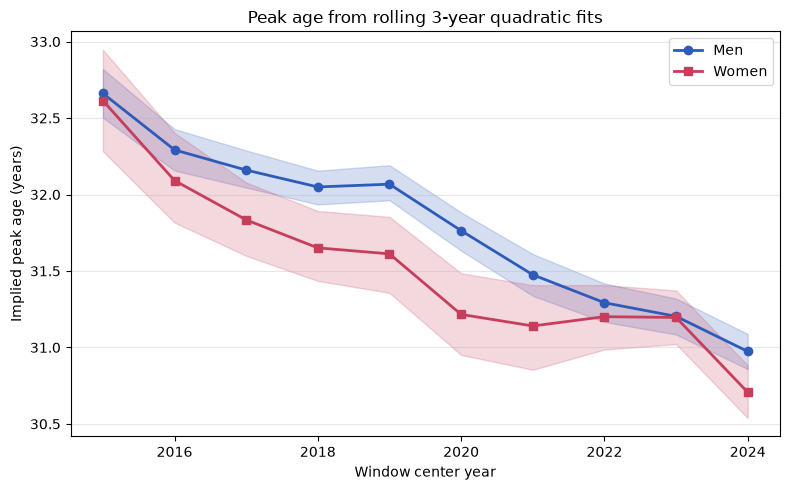

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

m = curves[curves["sex"] == "M"]
f = curves[curves["sex"] == "F"]

ax.plot(m["center_year"], m["peak_age"], "o-", color="#2E5BBA", linewidth=2, label="Men")
ax.fill_between(m["center_year"], m["lo"], m["hi"], color="#2E5BBA", alpha=0.2)
ax.plot(f["center_year"], f["peak_age"], "s-", color="#C73E5C", linewidth=2, label="Women")
ax.fill_between(f["center_year"], f["lo"], f["hi"], color="#C73E5C", alpha=0.2)

ax.set_xlabel("Window center year")
ax.set_ylabel("Implied peak age (years)")
ax.set_title("Peak age from rolling 3-year quadratic fits")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/02_peak_age.png", dpi=150, bbox_inches="tight")
plt.show()

Checking the shape and plotting the actual age curves for the earliest and latest windows side by side.

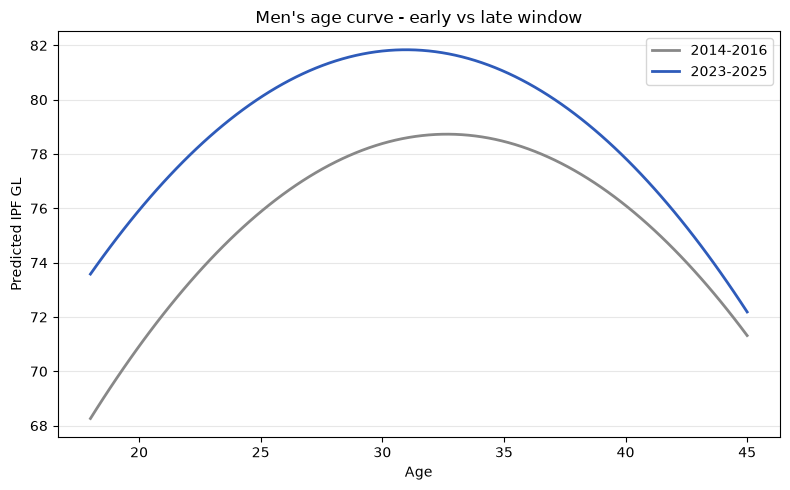

In [5]:
def curve_points(sub):
  x = sub["Age"].values
  y = sub["Goodlift"].values
  X = np.column_stack([np.ones_like(x), x, x**2])
  beta, *_ = np.linalg.lstsq(X, y, rcond=None)
  ages = np.linspace(18, 45, 100)
  preds = beta[0] + beta[1]*ages + beta[2]*ages**2
  return ages, preds

early = df[(df["Sex"] == "M") & (df["Year"].between(2014, 2016))]
late = df[(df["Sex"] == "M") & (df["Year"].between(2023, 2025))]

ax_e, pred_e = curve_points(early)
ax_l, pred_l = curve_points(late)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ax_e, pred_e, "-", color="#888", linewidth=2, label="2014-2016")
ax.plot(ax_l, pred_l, "-", color="#2E5BBA", linewidth=2, label="2023-2025")
ax.set_xlabel("Age")
ax.set_ylabel("Predicted IPF GL")
ax.set_title("Men's age curve - early vs late window")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/02_curves_early_vs_late.png", dpi=150, bbox_inches="tight")
plt.show()

The peak shift mirrors the headline finding - implied peak age drifts a couple years earlier across the window range, and the late curve is shifted up at every age (everyone's stronger now) and peaks earlier. Two caveats: the rolling-window OLS is fit on every observation in the window, so it's an overall age-performance shape rather than a within-lifter peak. Also no bootstrap CIs here - that would be the next add if a number ends up in the writeup.